# Matched Pairs Inference with Real Data: Sleep Study

This notebook starts from **real data** (downloaded from a stable public source) and walks through a full matched-pairs analysis:

- Reshape raw data into matched pairs
- Compute paired differences
- Build a **t-based confidence interval** for the mean difference
- Perform a **paired t-test**
- Check/record assumptions (normality of differences)
- Add a **nonparametric alternative** (Wilcoxon signed-rank test)

### Study design

Each subject receives **both** Drug 1 and Drug 2, and the response is the *increase in sleep* (hours). Because the same subjects appear in both conditions, we use the paired-difference model.

Let

$$
D_i = (\text{Drug2})_i - (\text{Drug1})_i, \quad i=1,\dots,n.
$$

We treat $\{D_i\}$ as i.i.d. draws from a population of differences with mean $\mu_d$ and variance $\sigma_d^2$.


In [24]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt

plt.rcParams["mathtext.fontset"] = "cm"

from classlib.plots import (
    annotate_xaxis_marks,
    shade_under_curve,
    curve_color,
    reject_color,
)

## Download the data

We load the classic `sleep` dataset from Rdatasets (a public mirror of many R datasets).

In [25]:
url = "https://vincentarelbundock.github.io/Rdatasets/csv/datasets/sleep.csv"
sleep = pd.read_csv(url)
n_records, n_var = sleep.shape
print(f"There are {n_records} records in this data set")
print(f"     and there are {n_var} variables for each record")
print(f"These variables are:")
sleep[["extra", "group", "ID"]].describe(include="all")
sleep

There are 20 records in this data set
     and there are 4 variables for each record
These variables are:


,rownames,extra,group,ID
0,1,0.7,1,1
1,2,-1.6,1,2
2,3,-0.2,1,3
3,4,-1.2,1,4
4,5,-0.1,1,5
5,6,3.4,1,6
6,7,3.7,1,7
7,8,0.8,1,8
8,9,0.0,1,9
9,10,2.0,1,10


Variables:

- `extra`: increase in sleep (hours)
- `group`: drug group (`1` or `2`)
- `ID`: subject ID


In [26]:
print("Here are some summary statistics")
sleep[["extra", "group", "ID"]].describe(include="all")

Here are some summary statistics


,extra,group,ID
count,20.00000,20.000000,20.000000
mean,1.54000,1.500000,5.500000
std,2.01792,0.512989,2.946898
min,-1.60000,1.000000,1.000000
25%,-0.02500,1.000000,3.000000
50%,0.95000,1.500000,5.500000
75%,3.40000,2.000000,8.000000
max,5.50000,2.000000,10.000000


## Reshape to matched pairs and compute differences

Since each record corresponds to one subject (ID) and one drug, we must combine them to get the difference for each subject 

In [27]:
sleep_wide = sleep.pivot(index="ID", columns="group", values="extra").copy()
sleep_wide.columns = ["Drug1", "Drug2"]
sleep_wide["Difference"] = sleep_wide["Drug2"] - sleep_wide["Drug1"]
sleep_wide

,Drug1,Drug2,Difference
ID,,,
1,0.7,1.9,1.2
2,-1.6,0.8,2.4
3,-0.2,1.1,1.3
4,-1.2,0.1,1.3
5,-0.1,-0.1,0.0
6,3.4,4.4,1.0
7,3.7,5.5,1.8
8,0.8,1.6,0.8
9,0.0,4.6,4.6


In [28]:
d = sleep_wide["Difference"].to_numpy()
n = d.size
mean_d = float(np.mean(d))
sd_d = float(np.std(d, ddof=1))
se_d = sd_d / np.sqrt(n)

mean_d, sd_d, se_d, n

(1.58, 1.2299954832798732, np.float64(0.3889587238883952), 10)

## Visualize the paired differences

A quick histogram is a good first check for skewness/outliers.

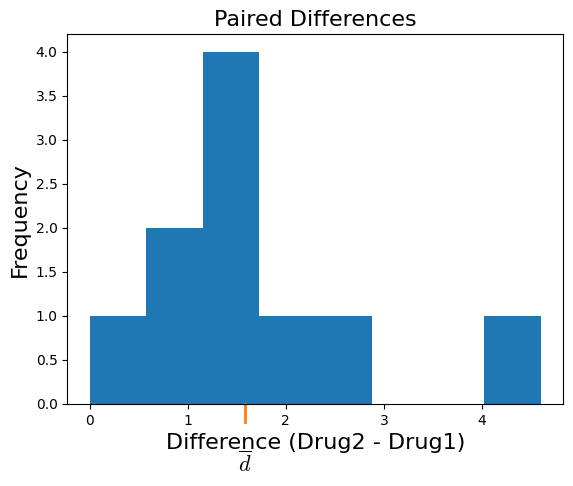

In [29]:
fig, ax = plt.subplots()
ax.hist(d, bins=8)
ax.set_xlabel("Difference (Drug2 - Drug1)", fontsize=16)
ax.set_ylabel("Frequency", fontsize=16)
ax.set_title("Paired Differences", fontsize=16)

# mark 0 and the sample mean
annotate_xaxis_marks(
    ax,
    xs=[mean_d],
    labels=[r"$\overline{d}$"],
    text_offset_pts=-34.0,
    fontsize=16,
)

plt.show()

## t-based confidence interval for $\mu_d$

Assuming the paired differences are approximately normal (or that the t procedures are adequate),
a $100(1-\alpha)\%$ CI for $\mu_d$ is

$$
\overline{d} \pm t_{1-\alpha/2,\;n-1}\;\frac{s_d}{\sqrt{n}}.
$$


In [30]:
alpha = 0.05
df = n - 1
t_star = st.t.ppf(1 - alpha/2, df)

ci_lower = mean_d - t_star * se_d
ci_upper = mean_d + t_star * se_d

(ci_lower, ci_upper)

(np.float64(0.7001142367012771), np.float64(2.4598857632987228))

In [31]:
print(f"n = {n}")
print(f"mean difference (Drug2 - Drug1) = {mean_d:.3f}")
print(f"sd of differences = {sd_d:.3f}")
print(f"95% CI for mu_d = ({ci_lower:.3f}, {ci_upper:.3f})")

n = 10
mean difference (Drug2 - Drug1) = 1.580
sd of differences = 1.230
95% CI for mu_d = (0.700, 2.460)


> **Assumption note (important)**  
> The paired t procedures assume the **distribution of paired differences** is (approximately) normal.
>
> - If $n$ is large, the CLT often makes the t procedures work well even with some non-normality.
> - Here $n=10$ is small, so we should at least **look** at the differences and record the assumption.
> - Later in the course, we can compare to a **nonparametric** paired alternative (Wilcoxon signed-rank).


## Paired t-test

We test

$$
H_0: \mu_d = 0
\quad \text{vs.} \quad
H_a: \mu_d \ne 0.
$$

The test statistic is

$$
t = \frac{\overline{d} - 0}{s_d/\sqrt{n}},
$$

which (under $H_0$ and normality of differences) follows a t distribution with $n-1$ degrees of freedom.


In [32]:
t_stat = mean_d / se_d
p_value = 2 * (1 - st.t.cdf(abs(t_stat), df))
t_stat, p_value

(np.float64(4.062127683382037), np.float64(0.002832890197384197))

In [33]:
print(f"t statistic = {t_stat:.3f} with df = {df}")
print(f"two-sided p-value = {p_value:.4f}")

t statistic = 4.062 with df = 9
two-sided p-value = 0.0028


Cross-check with SciPy:

In [34]:
st.ttest_rel(sleep_wide["Drug2"], sleep_wide["Drug1"])

TtestResult(statistic=np.float64(4.062127683382037), pvalue=np.float64(0.00283289019738427), df=np.int64(9))

## Visual: $t$ curve and two-sided $p$-value shading

Plotted on a semi-log scale to show the small $p$-value

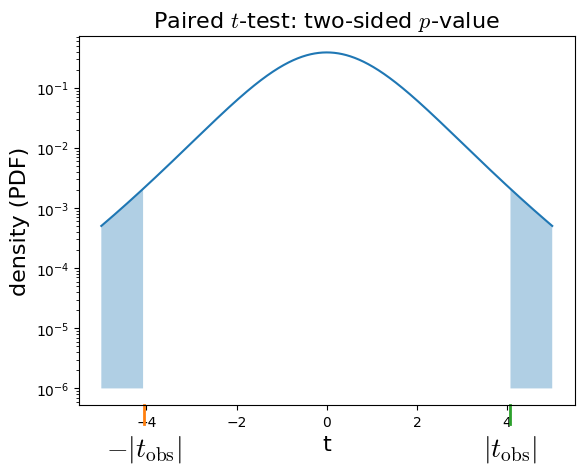

In [40]:
fig, ax = plt.subplots()

xs = np.linspace(-5, 5, 800)
ys = st.t.pdf(xs, df)
ax.plot(xs, ys)

ax.set_xlabel("t", fontsize=16)
ax.set_ylabel("density (PDF)", fontsize=16)
ax.set_title("Paired $t$-test: two-sided $p$-value", fontsize=16)

mask_left  = xs <= -abs(t_stat)
mask_right = xs >=  abs(t_stat)

shade_under_curve(ax, xs, ys, where=mask_left, baseline=1e-6, alpha=0.35)
shade_under_curve(ax, xs, ys, where=mask_right, baseline=1e-6, alpha=0.35)

ax.set_yscale("log")

annotate_xaxis_marks(
    ax,
    xs=[-abs(t_stat), abs(t_stat)],
    labels=[r"$-|t_{\mathrm{obs}}|$", r"$|t_{\mathrm{obs}}|$"],
    text_offset_pts=-20.0,
    fontsize = 20,
)

plt.show()

## Quick normality checks for the differences

These checks **do not prove normality**. They help us notice severe departures (strong skew/outliers).


### Q–Q plot

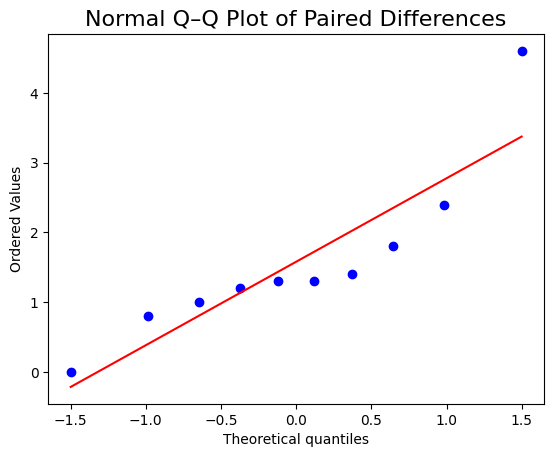

In [36]:
fig, ax = plt.subplots()
st.probplot(d, dist="norm", plot=ax)
ax.set_title("Normal Q–Q Plot of Paired Differences" , fontsize=16)
plt.show()

### Shapiro–Wilk test (optional)

Shapiro–Wilk tests $H_0$: “data are normally distributed.”

In [37]:
st.shapiro(d)

ShapiroResult(statistic=np.float64(0.8298713320953404), pvalue=np.float64(0.0333416087851208))

> **Interpretation warning**  
> Normality tests have limited power at small $n$ and can also be over-sensitive at large $n$.
>
> In practice, you should combine:
>
> - a plot-based check (hist/Q–Q),
> - knowledge of the data-generating process,
> - and (when appropriate) a robustness/nonparametric alternative.


## Nonparametric alternative: Wilcoxon signed-rank test

The Wilcoxon signed-rank test is a **nonparametric alternative to the paired $t$-test**.  
It tests whether the **median difference** between paired observations is zero.

Suppose the paired differences are

$$
d_i = X_i - Y_i, \qquad i=1,\dots,n.
$$

The test statistic is constructed as follows.

1. Remove any observations with $d_i = 0$.
2. Compute the absolute differences $|d_i|$.
3. Rank the absolute differences from smallest to largest.
4. Attach the **original signs** of $d_i$ to the ranks.

Let

- $W_+$ = sum of the ranks corresponding to **positive differences**
- $W_-$ = sum of the ranks corresponding to **negative differences**

Many texts define the Wilcoxon statistic as $W_+$.  
However, **SciPy reports**

$$
W = \min(W_+, W_-).
$$

Small values of $W$ indicate that the differences tend to go strongly in **one direction**.

In our example the result was

```
WilcoxonResult(statistic=0.0, pvalue=0.00390625)
```

Here

$$
W = 0,
$$

which means that **all observed differences had the same sign**.  
In our data all the differences were positive, so

$$
W_- = 0.
$$

This extreme directional pattern leads to a very small p-value, providing strong evidence against the null hypothesis that the median difference is zero.

In [38]:
from scipy.stats import rankdata
import numpy as np

# Remove zero differences (Wilcoxon rule)
mask = sleep_wide["Difference"] != 0
d = sleep_wide.loc[mask, "Difference"]

# Absolute differences
sleep_wide.loc[mask, "|Difference|"] = np.abs(d)

# Rank absolute differences
sleep_wide.loc[mask, "Rank"] = rankdata(np.abs(d))

# Sign
sleep_wide.loc[mask, "Sign"] = np.sign(d).map({1:"+", -1:"-"})

sleep_wide

,Drug1,Drug2,Difference,|Difference|,Rank,Sign
ID,,,,,,
1,0.7,1.9,1.2,1.2,3.0,+
2,-1.6,0.8,2.4,2.4,8.0,+
3,-0.2,1.1,1.3,1.3,4.5,+
4,-1.2,0.1,1.3,1.3,4.5,+
5,-0.1,-0.1,0.0,NaN,NaN,NaN
6,3.4,4.4,1.0,1.0,2.0,+
7,3.7,5.5,1.8,1.8,7.0,+
8,0.8,1.6,0.8,0.8,1.0,+
9,0.0,4.6,4.6,4.6,9.0,+


In [39]:
st.wilcoxon(d, alternative="two-sided")

WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(0.00390625))

## Summary (what to report)

- Data: matched pairs on $n$ subjects, response is sleep increase difference (Drug2 − Drug1).
- Parameter of interest: mean difference $\mu_d$ (and/or median difference for nonparametric analysis).
- 95% CI for $\mu_d$: report the interval from the CI section.
- Paired t-test: report $t$, df, and p-value.
- Assumption note: procedures rely on approximate normality of the paired differences.
- Wilcoxon signed-rank: report its p-value as a robustness/nonparametric comparison.
